In [ ]:
# Installing required packages
!pip install pyspark
!pip install findspark


In [ ]:
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext

##  Load the data


In [ ]:
spark = SparkSession \
    .builder \
    .appName("clustering") \
    .getOrCreate()

In [ ]:
sqlContext = SQLContext(spark)

/usr/local/lib/python3.11/dist-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


## Select input data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drybeans.csv to drybeans (1).csv


In [ ]:
file='drybeans.csv'
df = sqlContext.read.load(file,
                          format='com.databricks.spark.csv',
                          header='true',inferSchema='true')

In [ ]:
df.count()

13611

In [ ]:
df.describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
Area,13611,53048.284549261625,29324.09571688207,20420,254616
Perimeter,13611,855.2834585996654,214.28969589196151,524.736,1985.37
MajorAxisLength,13611,320.1418673032194,85.6941859593335,183.601165,738.8601535
MinorAxisLength,13611,202.2707140828817,44.97009129411471,122.5126535,460.1984968
AspectRation,13611,1.5832419790188144,0.24667845568580432,1.024867596,2.430306447
Eccentricity,13611,0.750894929372346,0.09200176320620888,0.218951263,0.911422968
ConvexArea,13611,53768.20020571596,29774.915817000012,20684,263261
EquivDiameter,13611,253.06421992490445,59.17712014871156,161.2437642,569.3743583
Extent,13611,0.7497327873564055,0.049086366843964224,0.555314717,0.866194641


In [ ]:
df =df.drop("Class")

In [ ]:
df.columns

['Area',
 'Perimeter',
 'MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Eccentricity',
 'ConvexArea',
 'EquivDiameter',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4']

# Prepare the features

In [ ]:
from pyspark.ml.feature import VectorAssembler

featuresUsed = df.columns[:-2]

assembler = VectorAssembler(inputCols=featuresUsed, outputCol="features")
assembled = assembler.transform(df)

# Choose number of cluster of Kmean

kmean seed is random

K-means is an iterative, centroid-based clustering algorithm that partitions a dataset into similar groups based on the distance between their centroids. The centroid, or cluster center, is either the mean or median of all the points within the cluster depending on the characteristics of the data.

Each cluster is represented by a single center (or centroid), and the algorithm aims to group data points around these centers.

In [ ]:
number_of_clusters = 3

In [ ]:
from pyspark.ml.clustering import KMeans
kmeans = KMeans(k = number_of_clusters)
kmeans.setSeed(555)

KMeans_82e87ea82409

In [ ]:
model = kmeans.fit(assembled)

# Make prediction and show evaluation

In [ ]:
predictions = model.transform(assembled)

In [ ]:
predictions.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|  520|
|         2| 3705|
|         0| 9386|
+----------+-----+



In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator()
cost = evaluator.evaluate(predictions)

In [ ]:
print(cost)

0.8262409265122557


In [ ]:
centers = model.clusterCenters()

no of elements in array = no of features. each center has center for each feature. avg center of that feature

we intialized the number of clusters (centroids) as 3, so we have 3 array of 16 features

In [ ]:
print(centers)

[array([3.94039515e+04, 7.41889991e+02, 2.75634793e+02, 1.81986018e+02,
       1.52297286e+00, 7.27881819e-01, 3.98756457e+04, 2.22868176e+02,
       7.50491938e-01, 9.88235576e-01, 8.95448863e-01, 8.15862914e-01,
       7.09631058e-03, 1.98013503e-03]), array([1.73708006e+05, 1.58682284e+03, 5.93746342e+02, 3.74494358e+02,
       1.58663498e+00, 7.71053829e-01, 1.76040635e+05, 4.69270023e+02,
       7.76670114e-01, 9.86888965e-01, 8.64297508e-01, 7.92303935e-01,
       3.44074408e-03, 8.42278487e-04]), array([7.06792305e+04, 1.03987472e+03, 3.94492493e+02, 2.29486871e+02,
       1.73544755e+00, 8.06365490e-01, 7.18016281e+04, 2.99216191e+02,
       7.44028928e-01, 9.84410220e-01, 8.18386308e-01, 7.60393312e-01,
       5.65239335e-03, 1.16929205e-03])]


This point, visually resembling an elbow on a graph, indicates where adding more clusters doesn't significantly improve the model's fit

In [ ]:
elbowset = assembled.select("features")
elbowset.persist()

DataFrame[features: vector]

# Data validation to find the best K

How to choose the best k for k-means = by using silhouette score
** k = number of clusters
- Compute the silhouette score for different values of  
K. The silhouette score measures how similar an object is to its own cluster compared to other clusters.

The silhouette score is a metric used to evaluate the quality of clusters produced by a clustering algorithm, such as k-means. It measures how well each data point fits into its assigned cluster compared to other clusters. The score ranges from -1 to +1, with higher values indicating better-defined and separated clusters

- Cost should be low = good

 A lower cost translates to reduced computational resources, faster processing times, and lower operational expenses, making the clustering process more practical and scalable (can handle big data), especially when dealing with large datasets

In [ ]:
import numpy as np
# Evaluate clustering by computing Silhouette score

cost = np.zeros(30)
for k in range(2,31):
    kmeans = KMeans()\
            .setK(k)\
            .setSeed(1)

    model = kmeans.fit(elbowset)
    prediction=model.transform(elbowset)
    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(prediction)
    cost[k-1] = silhouette

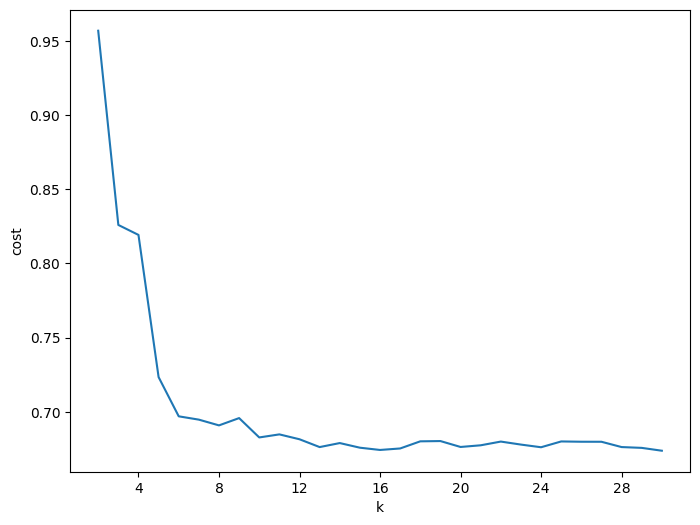

In [ ]:
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sbs
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1,1, figsize =(8,6))
ax.plot(range(2,31),cost[1:30])
ax.set_xlabel('k')
ax.set_ylabel('cost')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

#Scale the input data with 0 mean unit(1) variance

scaling data.
Standardization transforms the data to have a mean of zero and a standard deviation of one. This is done using the formula:

[ Z = \frac{(X - \mu)}{\sigma} ]

where (X) is the original value, (\mu) is the mean of the feature, and (\sigma) is its standard deviation

In [ ]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="features_std", withStd=True, withMean=True)
scalerModel = scaler.fit(assembled)
scaledData = scalerModel.transform(assembled)

In [ ]:
kmean = KMeans(k = number_of_clusters,featuresCol="features_std")

In [ ]:
model_std = kmean.fit(scaledData)

In [ ]:
prediction_std = model_std.transform(scaledData)


In [ ]:
prediction_std.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|  524|
|         2| 5472|
|         0| 7615|
+----------+-----+



In [ ]:
evaluator = ClusteringEvaluator()
cost = evaluator.evaluate(prediction_std)
print(cost)

0.6562242516772426


## Perform elbow plot in the range of 2 - 31

In [ ]:
elbowset = scaledData.select("features_std")
elbowset.persist()

DataFrame[features_std: vector]

In [ ]:
# Evaluate clustering by computing Silhouette score
cost = np.zeros(30)
for k in range(2,31):
    kmeans = KMeans(featuresCol="features_std")\
            .setK(k)\
            .setSeed(1)

    model = kmeans.fit(elbowset)
    prediction=model.transform(elbowset)
    evaluator = ClusteringEvaluator(featuresCol="features_std")
    silhouette = evaluator.evaluate(prediction)
    cost[k-1] = silhouette

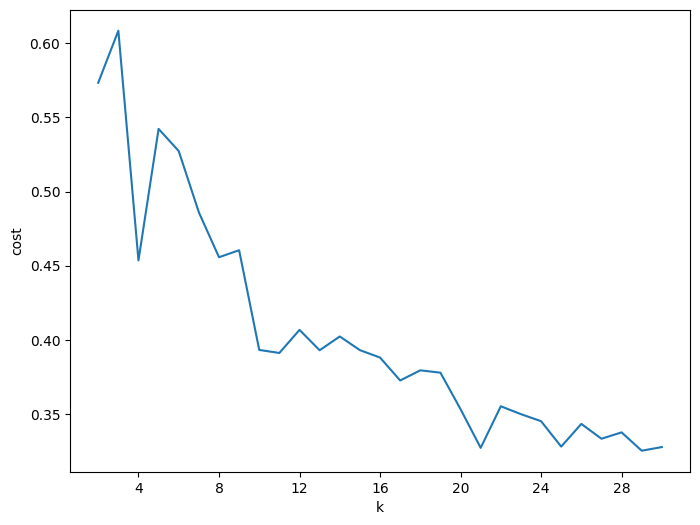

In [ ]:
fig, ax = plt.subplots(1,1, figsize =(8,6))
ax.plot(range(2,31),cost[1:30])
ax.set_xlabel('k')
ax.set_ylabel('cost')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

## Use K-mean with selected K
how many clusters should we have

k = 16?

In [ ]:
kmeans = KMeans(featuresCol="features_std",k=16, seed=1)
model = kmeans.fit(scaledData)
transformed = model.transform(scaledData)

In [ ]:
centers = model.clusterCenters()
centers

[array([-0.27106765, -0.24630384, -0.21519617, -0.25403854, -0.00375084,
         0.24026409, -0.27217665, -0.23198718, -0.84494563,  0.09957295,
         0.0838035 , -0.09902822,  0.14008995, -0.11414541]),
 array([ 3.54626033,  3.00074074,  2.70421199,  3.60129428, -0.26613801,
        -0.03400598,  3.52945256,  3.2720126 ,  0.53429519,  0.29450144,
         0.07219436,  0.17006702, -2.69141685, -1.30027223]),
 array([ 0.77188758,  0.99212946,  1.06984975,  0.75980983,  0.64873464,
         0.72319852,  0.79242568,  0.95938772,  0.19213385, -1.89438235,
        -0.7054417 , -0.76022819, -0.95983199, -1.05264118]),
 array([-0.55343792, -0.73523581, -1.02752905, -0.01301331, -1.7498029 ,
        -2.82265399, -0.55623623, -0.62340552,  0.56367309,  0.52727184,
         1.26118481,  2.13285   , -0.19364185,  2.06468466]),
 array([-4.08826074e-03,  3.46493882e-01,  3.57088219e-01, -1.77461302e-01,
         9.10501194e-01,  7.95906082e-01,  3.55983941e-02,  7.75079671e-02,
        -8.12816

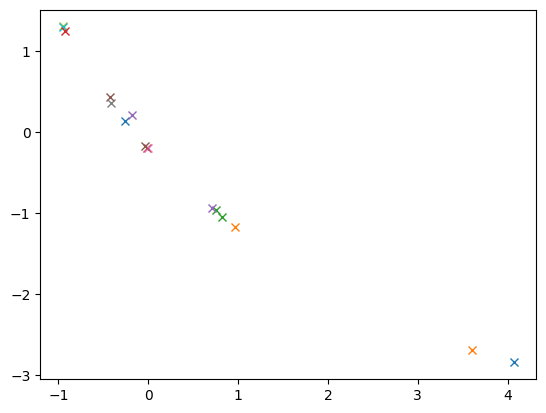

In [ ]:
for k in range(0,16):
    plt.plot(centers[k][3],centers[k][12],'x')


In [ ]:
spark.stop()